In [10]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [11]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
language = 'english'

batch_shuffle = 0
centers_list = ['syn']
min_token_length = 6
n_files = 16
batch_size = 100
n_tokens_list = [min_token_length]
avg_flags = [0]
Nbits = 0
match_vars = ['matching']
data_vars = ['sem']
zero_activations_list = [0]
center_B_flags = [1]
center_A_flags = [1]
similarity_fn = 'normalized_L2_distance'

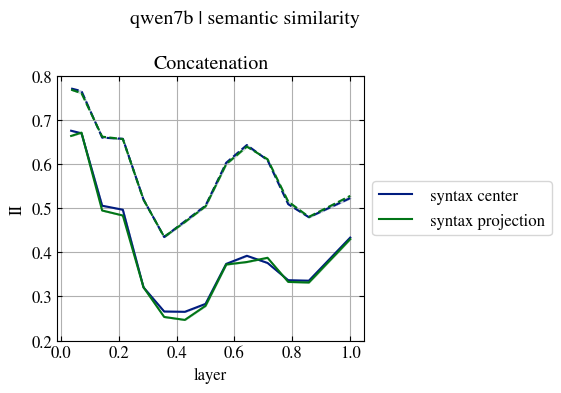

In [13]:
precision = 32

fig, ax = plt.subplots(figsize=(5,4))   # just one axis
title = ''
global_centerings = [1]
avg_tokens = 0

for global_id, global_centering in enumerate(global_centerings):
    plot_id = 0
    global_id += 1 

    for random_center_type_0 in [None]:
        for removal_method_0 in ['subtraction','projection']:
            _removal_method = 'projection' if removal_method_0 == 'projection' else 'center'
            for zero_id, zero_activations in enumerate(zero_activations_list):
                for center_A_id, center_A_flag in enumerate(center_A_flags):
                    for center_B_id, center_B_flag in enumerate(center_B_flags):
                        if center_A_flag != center_B_flag: 
                            continue
                        if random_center_type_0 == None and center_A_flag == -1:
                            continue 
                        if center_A_flag == 1 and random_center_type_0 != None:
                            continue
                        if center_A_flag == 0 and (removal_method_0 != None or random_center_type_0 != None):
                            continue
                        if removal_method_0 == None and (random_center_type_0 != None or center_A_flag != 0):
                            continue

                        for data_var_id, data_var in enumerate(data_vars):
                            for centers_id, centers in enumerate(centers_list):
                                for match_id, match_var in enumerate(match_vars):
                                    for n_tokens in n_tokens_list:
                                        if match_var == 'mismatching' and center_A_flag != 0:
                                            continue
                                        output_folder0 = makefolder(base=f'./results/',
                                                                    global_centering=global_centering,
                                                                    spaces='AB',
                                                                    similarity_fn=similarity_fn,
                                                                    precision=precision,
                                                                    language=language,
                                                                    data_var=data_var,
                                                                    modelA=modelA,
                                                                    modelB=modelB,
                                                                    match_var=match_var,
                                                                    n_files=n_files,
                                                                    min_token_length=min_token_length,
                                                                    )
                                        II_folder = makefolder(base=output_folder0,
                                                               centers=centers,
                                                               Nbits=Nbits,
                                                               n_tokens=n_tokens,
                                                               avg_tokens=avg_tokens,
                                                               batch_shuffle=batch_shuffle,
                                                               zero_activations=zero_activations,
                                                               center_A_flag=center_A_flag,
                                                               center_B_flag=center_B_flag,
                                                               removal_method=removal_method_0,
                                                               random_center_type=random_center_type_0,
                                                               )
                                        inf_imb = np.load(II_folder + "II.npy")
                                        std = np.load(II_folder + "II_jack_std.npy")

                                        layers_A = list(range(1, depths[modelA] + 1))
                                        layers_B = list(range(1, depths[modelB] + 1))
                                        layers = np.array(reduce_list_half_preserve_extremes(layers_A), dtype=float)
                                        layers /= depths[modelB]
                                        color = colors[plot_id % len(colors)] 
                                        linestyle = '-'
                                        if avg_tokens:
                                            title = f'Average'
                                        else:
                                            title = f'Concatenation'

                                        label = ''
                                        if center_A_flag == 0:
                                            label += 'semantic similarity'
                                        if center_A_flag == -1:
                                            label += f' {random_center_type_0} {_removal_method}'
                                        if center_A_flag == 1:
                                            label += f' syntax {_removal_method}'

                                        for II_index in range(2):
                                            if II_index == 1:
                                                label = None
                                            ax.plot(layers,
                                                    inf_imb[II_index].diagonal(),
                                                    label=label,
                                                    linestyle=_linestyles[II_index],
                                                    color=color,
                                                    ) 
                                            ax.fill_between(layers,
                                                            inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                                            inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                                            alpha=0.2,
                                                            color=color,
                                                            )
                                        plot_id += 1

ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_ylim(0.2, .8)
ax.tick_params(
    top=True, bottom=True, left=True, right=True,  
    labeltop=False, labelbottom=True, labelleft=True, labelright=False, 
    direction='in'  
)
ax.grid()
ax.set_title(title)

fig.suptitle(f' {modelA} | semantic similarity')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/decoupling_sem_syn_{modelA}_avg_{avg_tokens}.pdf', bbox_inches='tight')
plt.show()
